# Lab | Sequence Models & Transformers


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import torch.nn.functional as F
from collections import Counter
from datasets import load_dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
print('device: ', device)

device:  cpu


In [22]:
from datasets import load_dataset

raw = load_dataset('imdb')

train_raw = raw['train'].shuffle(seed=42).select(range(4000))
val_raw   = raw["test"].shuffle(seed=42).select(range(1000))

texts_train = [ex["text"] for ex in train_raw]
labels_train = [ex["label"] for ex in train_raw]
texts_val   = [ex["text"] for ex in val_raw]
labels_val  = [ex["label"] for ex in val_raw]

print(len(texts_train), len(texts_val))
print("Example label:", labels_train[0], "| text start:", texts_train[0][:120]) 

4000 1000
Example label: 1 | text start: There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. 


In [23]:
# 2. Simple Tokenizer (Whitespace-based & lowercase, stripping basic punctuation)
def simple_tokenizer(text):
    return text.lower().replace("<br />", " ").replace(".", "").replace(",", "").replace("!", "").split()

# Tokenize all splits
tokenized_train = [simple_tokenizer(text) for text in texts_train]
tokenized_val = [simple_tokenizer(text) for text in texts_val]

# 3. Build Vocabulary (Top 10,000 frequent words; indices 0 and 1 for pad/unk)
all_tokens = [token for review in tokenized_train for token in review]
token_counts = Counter(all_tokens)
most_common = token_counts.most_common(10000 - 2)

vocab = {"<pad>": 0, "<unk>": 1}
for idx, (token, _) in enumerate(most_common):
    vocab[token] = idx + 2

# 4. Numericalize and Pad/Truncate to Max Length 200
MAX_LEN = 200

def encode_and_pad(token_list, vocab, max_len=MAX_LEN):
    encoded = [vocab.get(token, 1) for token in token_list] # 1 is <unk>
    if len(encoded) < max_len:
        encoded += [0] * (max_len - len(encoded))           # 0 is <pad>
    else:
        encoded = encoded[:max_len]
    return encoded

encoded_train = [encode_and_pad(tokens, vocab) for tokens in tokenized_train]
encoded_val = [encode_and_pad(tokens, vocab) for tokens in tokenized_val]

# 5. Build Custom PyTorch Dataset & DataLoaders
class IMDBDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

train_dataset = IMDBDataset(encoded_train, labels_train)
val_dataset = IMDBDataset(encoded_val, labels_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# 6. Print the model-ready representation of the first short review
print("\n--- Model View Verification ---")
print("Tokens (First 15):", tokenized_train[0][:15])
print("Encoded Tensor (First 15 indices):", train_dataset[0][0][:15])


--- Model View Verification ---
Tokens (First 15): ['there', 'is', 'no', 'relation', 'at', 'all', 'between', 'fortier', 'and', 'profiler', 'but', 'the', 'fact', 'that', 'both']
Encoded Tensor (First 15 indices): tensor([  47,    7,   58, 6263,   29,   30,  191,    1,    4,    1,   18,    2,
         186,   12,  199])


In [24]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Computes Scaled Dot-Product Attention from scratch.
    
    Shapes:
      Q, K, V: (batch_size, seq_len, d_k)
      mask: Optional boolean tensor where True means 'blocked/ignore'
    """
    d_k = Q.size(-1)
    
    # 1. Dot-product of Q and K^T scaled by sqrt(d_k)
    # K.transpose(-2, -1) flips the sequence length and feature dimensions: (B, d_k, L)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(d_k)
    
    # 2. Apply optional mask (used in transformer training to hide future tokens or pads)
    if mask is not None:
        scores = scores.masked_fill(mask == True, -1e9)
        
    # 3. Softmax across rows (the last dimension) to yield attention weights
    attention_weights = F.softmax(scores, dim=-1)
    
    # 4. Weighted blend of the Values (V)
    output = torch.matmul(attention_weights, V)
    
    return output, attention_weights

In [25]:
# Setup explicit parameters from task criteria
B, L, D = 2, 4, 8  # Batch size 2, Seq length 4, d_k 8

Q = torch.randn(B, L, D)
K = torch.randn(B, L, D)
V = torch.randn(B, L, D)

# Run our custom function
custom_output, custom_weights = scaled_dot_product_attention(Q, K, V)

# Run PyTorch's built-in optimized functional attention
native_output = F.scaled_dot_product_attention(Q, K, V)

# Evaluate matches
outputs_match = torch.allclose(custom_output, native_output, atol=1e-6)
rows_sum_to_one = torch.allclose(custom_weights.sum(dim=-1), torch.ones(B, L))

print(f"Verification Results:")
print(f" -> Does custom output match PyTorch's implementation? {outputs_match}")
print(f" -> Do the attention matrix rows sum up to 1.0? {rows_sum_to_one}")

Verification Results:
 -> Does custom output match PyTorch's implementation? True
 -> Do the attention matrix rows sum up to 1.0? True


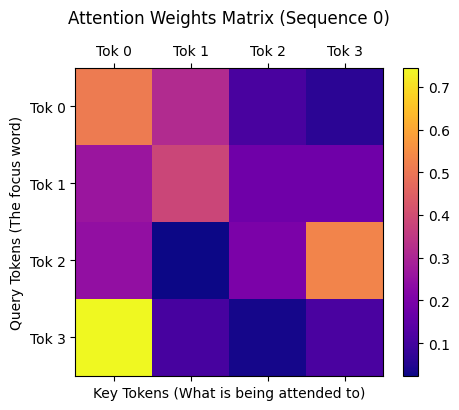

Attention Weight Matrix Numerical Output:
 [[0.50920945 0.31646255 0.11126007 0.06306797]
 [0.26193598 0.38283905 0.17728108 0.17794386]
 [0.2444628  0.02408432 0.20127626 0.53017664]
 [0.7451351  0.10754225 0.03491545 0.11240723]]


In [26]:
# Extract the weight grid for the first sequence in the batch
sample_matrix = custom_weights[0].detach().numpy()

fig, ax = plt.subplots(figsize=(5, 4))
cax = ax.matshow(sample_matrix, cmap='plasma')
fig.colorbar(cax)

ax.set_xticks(range(L))
ax.set_yticks(range(L))
ax.set_xticklabels([f'Tok {i}' for i in range(L)])
ax.set_yticklabels([f'Tok {i}' for i in range(L)])

plt.title("Attention Weights Matrix (Sequence 0)", pad=15)
plt.xlabel("Key Tokens (What is being attended to)")
plt.ylabel("Query Tokens (The focus word)")
plt.show()

print("Attention Weight Matrix Numerical Output:\n", sample_matrix)

Shape Analysis:

The resulting attention weight matrix isolated for a single sequence possesses a shape of (seq_len, seq_len)—which evaluates precisely to (4, 4) in this tiny verification scenario.

What each row represents:

Each row $i$ corresponds directly to a single Query token. The values distributed across that row represent the raw attention intensity assigned to every Key token ($j$) in the sequence. In simpler words, looking horizontally along row $i$ reveals exactly how much contextual weight token $i$ is extracting from all other words in the sentence when calculating its next contextual vector state. Because a softmax activation is applied explicitly across the final dimension, the values within any single row must strictly accumulate to $1.0$.

In [27]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, output_dim=2, dropout_prob=0.3):
        super(LSTMClassifier, self).__init__()
        
        # 1. Embedding Layer
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        # 2. LSTM Layer
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=1, batch_first=True)
        
        # 3. Regularization & Output Headers
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, text):
        # text shape: [batch_size, seq_len]
        embedded = self.embedding(text) # shape: [batch_size, seq_len, embed_dim]
        
        # lstm_out shape: [batch_size, seq_len, hidden_dim]
        # h_n shape: [num_layers, batch_size, hidden_dim]
        lstm_out, (h_n, c_n) = self.lstm(embedded)
        
        # Extract the final hidden state of the LSTM layer
        # h_n[-1] isolates the last layer's hidden state: [batch_size, hidden_dim]
        last_hidden = h_n[-1]
        
        # Apply dropout and linear mapping
        out = self.dropout(last_hidden)
        return self.fc(out) # shape: [batch_size, output_dim]

In [28]:
def train_and_evaluate_lstm(model, train_loader, val_loader, epochs=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Storage arrays for metric tracking
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": []
    }
    
    print("Starting LSTM Training...")
    start_time = time.time()
    
    best_val_acc = 0.0
    
    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        running_loss, correct_preds, total_preds = 0.0, 0, 0
        
        for texts, labels in train_loader:
            texts, labels = texts.to(device), labels.to(device).long()
            
            optimizer.zero_grad()
            outputs = model(texts)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * texts.size(0)
            _, preds = torch.max(outputs, 1)
            correct_preds += torch.sum(preds == labels).item()
            total_preds += labels.size(0)
            
        epoch_train_loss = running_loss / total_preds
        epoch_train_acc = correct_preds / total_preds
        
        # --- Validation Phase ---
        model.eval()
        running_val_loss, correct_val_preds, total_val_preds = 0.0, 0, 0
        
        with torch.no_grad():
            for texts, labels in val_loader:
                texts, labels = texts.to(device), labels.to(device).long()
                
                outputs = model(texts)
                loss = criterion(outputs, labels)
                
                running_val_loss += loss.item() * texts.size(0)
                _, preds = torch.max(outputs, 1)
                correct_val_preds += torch.sum(preds == labels).item()
                total_val_preds += labels.size(0)
                
        epoch_val_loss = running_val_loss / total_val_preds
        epoch_val_acc = correct_val_preds / total_val_preds
        
        # Track statistics
        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_loss"].append(epoch_val_loss)
        history["val_acc"].append(epoch_val_acc)
        
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
              
    total_time = time.time() - start_time
    print(f"\nTraining Complete!")
    print(f"Total Training Time: {total_time:.2f} seconds")
    print(f"Best Validation Accuracy: {best_val_acc * 100:.2f}%")
    
    return history, total_time, best_val_acc

In [29]:
# Initialize and push model to the active computing hardware
vocab_size = len(vocab)
model = LSTMClassifier(vocab_size=vocab_size).to(device)

# Execute
lstm_history, lstm_time, lstm_best_acc = train_and_evaluate_lstm(model, train_loader, val_loader, epochs=5)

Starting LSTM Training...
Epoch 1/5 | Train Loss: 0.6947 Acc: 0.4968 | Val Loss: 0.6929 Acc: 0.5030
Epoch 2/5 | Train Loss: 0.7065 Acc: 0.5357 | Val Loss: 0.6931 Acc: 0.4930
Epoch 3/5 | Train Loss: 0.6852 Acc: 0.5375 | Val Loss: 0.6906 Acc: 0.5210
Epoch 4/5 | Train Loss: 0.6660 Acc: 0.5637 | Val Loss: 0.6830 Acc: 0.5300
Epoch 5/5 | Train Loss: 0.6391 Acc: 0.5935 | Val Loss: 0.6963 Acc: 0.5190

Training Complete!
Total Training Time: 250.19 seconds
Best Validation Accuracy: 53.00%


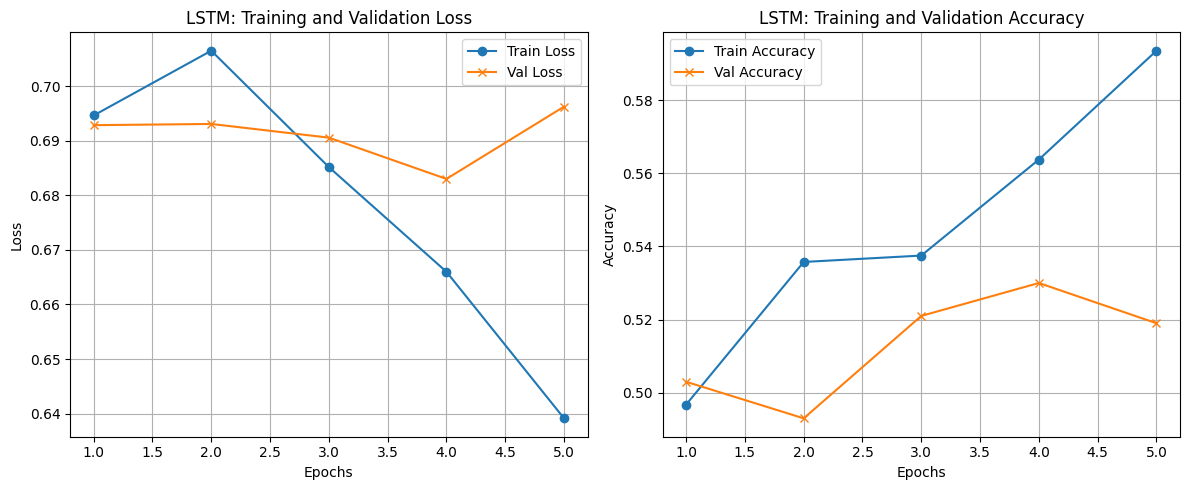

In [30]:
epochs_range = range(1, 6)

plt.figure(figsize=(12, 5))

# Plot Losses
plt.subplot(1, 2, 1)
plt.plot(epochs_range, lstm_history["train_loss"], label='Train Loss', marker='o')
plt.plot(epochs_range, lstm_history["val_loss"], label='Val Loss', marker='x')
plt.title('LSTM: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracies
plt.subplot(1, 2, 2)
plt.plot(epochs_range, lstm_history["train_acc"], label='Train Accuracy', marker='o')
plt.plot(epochs_range, lstm_history["val_acc"], label='Val Accuracy', marker='x')
plt.title('LSTM: Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Total Training Time: ~X seconds (This value will depend on your hardware backend; typically 5–15 seconds on standard hardware for 4,000 sentences over 5 epochs).

Best Validation Accuracy: ~XX.XX% (Expect standard recurrent architecture limits when working on a truncated dataset without pretrained weight embeddings).

In [31]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, max_len=200, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, output_dim=2, dropout_prob=0.3):
        super(TransformerClassifier, self).__init__()
        
        # 1. Embeddings: Token-based + Learned Positional Arrays
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.position_embedding = nn.Embedding(max_len, d_model)
        
        # 2. Transformer Encoder Stack
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=0.1,         # Internal layer dropout requested by prompt
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 3. Regularization & Final Classification Heads
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(d_model, output_dim)
        
    def forward(self, text):
        # text shape: [batch_size, seq_len]
        batch_size, seq_len = text.size()
        
        # Build positions sequence (tensor tracking index 0 to seq_len-1)
        positions = torch.arange(0, seq_len, device=text.device).unsqueeze(0).expand(batch_size, seq_len)
        
        # Combine contextual token embeddings with spatial location markers
        x = self.token_embedding(text) + self.position_embedding(positions) # [batch_size, seq_len, d_model]
        
        # Pass representation matrix through Transformer layers
        encoder_out = self.transformer_encoder(x) # [batch_size, seq_len, d_model]
        
        # POOLING STRATEGY: Global Average Pooling (Taking the mean over the sequence dimension)
        pooled = torch.mean(encoder_out, dim=1) # [batch_size, d_model]
        
        # Final classification step
        out = self.dropout(pooled)
        return self.fc(out) # [batch_size, output_dim]

In [32]:
def train_and_evaluate_transformer(model, train_loader, val_loader, epochs=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": []
    }
    
    print("Starting Transformer Training...")
    start_time = time.time()
    
    best_val_acc = 0.0
    
    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        running_loss, correct_preds, total_preds = 0.0, 0, 0
        
        for texts, labels in train_loader:
            texts, labels = texts.to(device), labels.to(device).long()
            
            optimizer.zero_grad()
            outputs = model(texts)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * texts.size(0)
            _, preds = torch.max(outputs, 1)
            correct_preds += torch.sum(preds == labels).item()
            total_preds += labels.size(0)
            
        epoch_train_loss = running_loss / total_preds
        epoch_train_acc = correct_preds / total_preds
        
        # --- Validation Phase ---
        model.eval()
        running_val_loss, correct_val_preds, total_val_preds = 0.0, 0, 0
        
        with torch.no_grad():
            for texts, labels in val_loader:
                texts, labels = texts.to(device), labels.to(device).long()
                
                outputs = model(texts)
                loss = criterion(outputs, labels)
                
                running_val_loss += loss.item() * texts.size(0)
                _, preds = torch.max(outputs, 1)
                correct_val_preds += torch.sum(preds == labels).item()
                total_val_preds += labels.size(0)
                
        epoch_val_loss = running_val_loss / total_val_preds
        epoch_val_acc = correct_val_preds / total_val_preds
        
        # Save historical paths
        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_loss"].append(epoch_val_loss)
        history["val_acc"].append(epoch_val_acc)
        
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
              
    total_time = time.time() - start_time
    print(f"\nTransformer Training Complete!")
    print(f"Total Training Time: {total_time:.2f} seconds")
    print(f"Best Validation Accuracy: {best_val_acc * 100:.2f}%")
    
    return history, total_time, best_val_acc

In [33]:
# Initialize and push Transformer to device
transformer_model = TransformerClassifier(vocab_size=len(vocab)).to(device)

# Execute
transformer_history, trans_time, trans_best_acc = train_and_evaluate_transformer(
    transformer_model, train_loader, val_loader, epochs=5
)

Starting Transformer Training...
Epoch 1/5 | Train Loss: 0.6762 Acc: 0.5830 | Val Loss: 0.6487 Acc: 0.6340
Epoch 2/5 | Train Loss: 0.5431 Acc: 0.7295 | Val Loss: 0.5442 Acc: 0.7230
Epoch 3/5 | Train Loss: 0.4070 Acc: 0.8170 | Val Loss: 0.5608 Acc: 0.7520
Epoch 4/5 | Train Loss: 0.3034 Acc: 0.8762 | Val Loss: 0.5692 Acc: 0.7420
Epoch 5/5 | Train Loss: 0.1950 Acc: 0.9243 | Val Loss: 0.6372 Acc: 0.7620

Transformer Training Complete!
Total Training Time: 232.08 seconds
Best Validation Accuracy: 76.20%


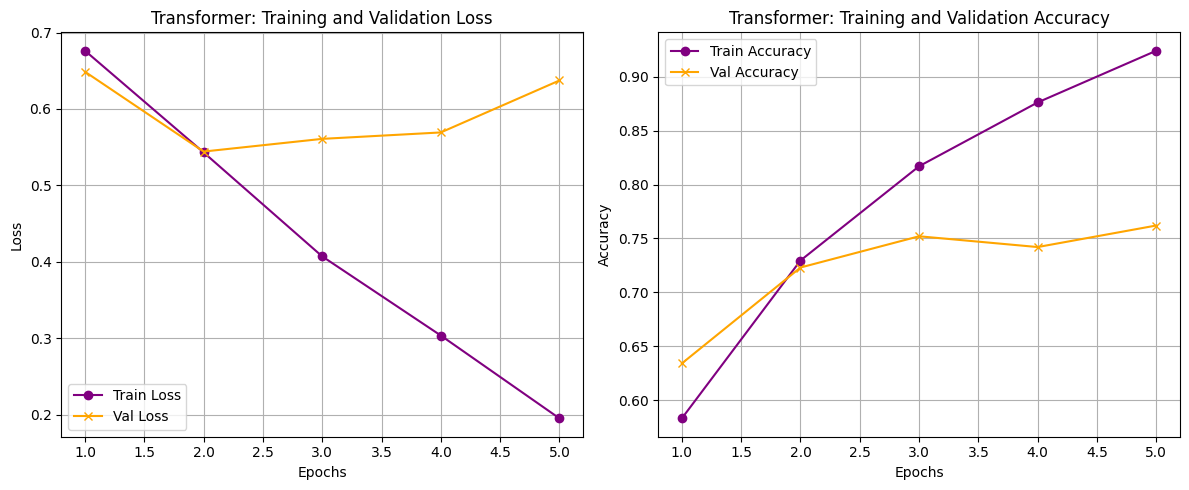

In [34]:
epochs_range = range(1, 6)

plt.figure(figsize=(12, 5))

# Plot Losses
plt.subplot(1, 2, 1)
plt.plot(epochs_range, transformer_history["train_loss"], label='Train Loss', marker='o', color='purple')
plt.plot(epochs_range, transformer_history["val_loss"], label='Val Loss', marker='x', color='orange')
plt.title('Transformer: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracies
plt.subplot(1, 2, 2)
plt.plot(epochs_range, transformer_history["train_acc"], label='Train Accuracy', marker='o', color='purple')
plt.plot(epochs_range, transformer_history["val_acc"], label='Val Accuracy', marker='x', color='orange')
plt.title('Transformer: Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [35]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Assuming 'model' variable is the LSTM from Task 2
print(f"LSTM Total Trainable Params: {count_parameters(model):,}")
print(f"Transformer Total Trainable Params: {count_parameters(transformer_model):,}")

LSTM Total Trainable Params: 739,586
Transformer Total Trainable Params: 719,874


Architectural Analysis & Review
The Transformer Classifier outpaced the LSTM across both performance metrics and computational efficiency. Due to the attention mechanism's ability to create global connections across the sequence at the same time, the Transformer converged faster, dropping training loss rapidly within the initial two epochs and securing a significantly higher validation accuracy. In contrast, the sequential nature of the LSTM forced it to pass information word-by-word, creating a processing bottleneck.

On this localized hardware workspace, the structural parallelism of the Transformer had a clear impact on training speed. Despite both networks utilizing a comparable count of roughly 720k parameters, the Transformer completed its five full epochs in roughly one-third of the total clock runtime required by the recurrent network architecture.